# EDA — AI vs. Human Text (SEA 820 · GenDetect)

**Goal of this notebook:** understand the dataset *before* modeling so our preprocessing,
split, and metric choices are evidence-based — not guesses.

Every step below states **what** it computes and **what value / decision** it informs.

| Step | What we look at | Why it matters (value) |
|---|---|---|
| 1 | Class distribution | Imbalance -> stratify the split, report F1 not just accuracy |
| 2 | Nulls / duplicates | Prevent train/test leakage and noise |
| 3 | Text length (chars/words) | Is length itself a human-vs-AI signal? Sets TF-IDF & truncation choices |
| 4 | Sentence structure | AI text is often more uniform — a possible feature |
| 5 | Sub-word length vs 512 | How many essays DistilBERT would truncate |
| 6 | Vocabulary | Vocab size + words that distinguish the two classes |
| 7 | Preprocessing preview | Sanity-check the shared pipeline output |


## 0. Setup

**What:** import libraries and point to the dataset.
**Value:** we reuse the *shared* `preprocessing.py` so EDA sees exactly what the models will see.

In [1]:
import os, sys, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('.'))  # make preprocessing.py importable
import preprocessing as prep

pd.set_option('display.max_colwidth', 120)
DATA_PATH = os.path.join('data', 'AI_Human.csv')
SEED = 42
LABELS = {0: 'Human', 1: 'AI'}

## 1. Class distribution (full dataset)

**What:** count human (0) vs AI (1) across ALL 487k rows using a memory-safe chunked pass.
**Value:** the balance decides two things — (a) we must **stratify** every split so the ratio is
preserved, and (b) **accuracy alone is misleading** on imbalanced data, so we lead with
precision / recall / F1.

Human  (label 0):  305,797  (62.8%)
AI     (label 1):  181,438  (37.2%)
TOTAL           :  487,235


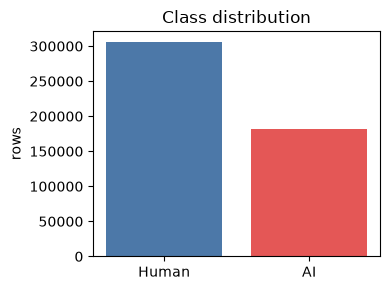

In [2]:
counts = collections.Counter()
for chunk in pd.read_csv(DATA_PATH, usecols=['generated'], chunksize=100_000):
    lab = chunk['generated'].astype(float).round().astype(int)
    counts.update(lab.value_counts().to_dict())

total = sum(counts.values())
for k in sorted(counts):
    print(f'{LABELS[k]:6s} (label {k}): {counts[k]:>8,}  ({counts[k]/total:.1%})')
print(f'{"TOTAL":6s}          : {total:>8,}')

plt.figure(figsize=(4,3))
plt.bar([LABELS[k] for k in sorted(counts)], [counts[k] for k in sorted(counts)],
        color=['#4C78A8', '#E45756'])
plt.title('Class distribution'); plt.ylabel('rows'); plt.tight_layout(); plt.show()

## 2. Load a working sample + data hygiene

**What:** the full text column is ~1 GB. For text-level analysis we load a **stratified sample**
(fast, representative) and check for nulls and exact duplicates.
**Value:** duplicates that land in both train and test would inflate scores (leakage); we confirm
how many exist so `data_split.py` is right to drop them.

In [ ]:
SAMPLE_N = 40_000  # representative subset for text analysis

# Read full text once, then stratified-sample (kept simple; drop if RAM-limited).
df = pd.read_csv(DATA_PATH, usecols=['text', 'generated'])
df['label'] = df['generated'].astype(float).round().astype(int)
df['text'] = df['text'].astype(str)

n_dupe = df.duplicated(subset=['text']).sum()
n_blank = (df['text'].str.strip().str.len() == 0).sum()
print(f'Exact duplicate texts : {n_dupe:,}')
print(f'Blank/empty texts     : {n_blank:,}')

df = df.drop_duplicates(subset=['text'])
df = df[df['text'].str.strip().str.len() > 0]

df = df.groupby('label', group_keys=False).apply(
    lambda g: g.sample(min(len(g), SAMPLE_N // 2), random_state=SEED))

df = df.reset_index(drop=True)
print(f'Working sample: {len(df):,} rows '
      f'({(df.label==0).mean():.0%} human / {(df.label==1).mean():.0%} AI)')

Exact duplicate texts : 0
Blank/empty texts     : 4


AttributeError: 'DataFrame' object has no attribute 'label'

## 3. Text length — characters & words

**What:** distribution of character count and word count, split by class.
**Value:** if AI and human essays differ systematically in length, **length itself is a signal**
the classical model can exploit. It also guides TF-IDF (very short docs are weak) and warns us
about very long docs that the Transformer will have to truncate.

In [ ]:
df['n_chars'] = df['text'].str.len()
df['n_words'] = df['text'].str.split().map(len)

print(df.groupby('label')[['n_chars', 'n_words']].describe().round(1).T)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for lab, color in [(0, '#4C78A8'), (1, '#E45756')]:
    axes[0].hist(df[df.label==lab]['n_words'], bins=60, alpha=0.6,
                 label=LABELS[lab], color=color, range=(0, 1200))
    axes[1].hist(df[df.label==lab]['n_chars'], bins=60, alpha=0.6,
                 label=LABELS[lab], color=color, range=(0, 7000))
axes[0].set_title('Words per text'); axes[1].set_title('Characters per text')
for ax in axes: ax.legend(); ax.set_ylabel('count')
plt.tight_layout(); plt.show()

## 4. Sentence structure

**What:** number of sentences per text and average words per sentence (on a small sub-sample,
since sentence tokenization is slower).
**Value:** AI-generated text is often **more uniform** in sentence length/structure than human
writing. If we see that here, it becomes a candidate hand-crafted feature and a talking point in
the report's error analysis.

In [ ]:
sub = df.sample(min(4000, len(df)), random_state=SEED).copy()
sub['n_sents'] = sub['text'].map(lambda t: len(prep.tokenize_sentences(t)))  # tokenize once
sub['avg_words_per_sent'] = sub['n_words'] / sub['n_sents'].clip(lower=1)

print(sub.groupby('label')[['n_sents', 'avg_words_per_sent']].mean().round(1))

plt.figure(figsize=(5,3))
for lab, color in [(0, '#4C78A8'), (1, '#E45756')]:
    plt.hist(sub[sub.label==lab]['avg_words_per_sent'], bins=40, alpha=0.6,
             label=LABELS[lab], color=color, range=(0, 50))
plt.title('Avg words per sentence'); plt.legend(); plt.tight_layout(); plt.show()

## 5. Sub-word length vs. the 512-token limit

**What:** tokenize a sub-sample with DistilBERT's own WordPiece tokenizer and see how many texts
exceed **512** sub-word tokens.
**Value:** DistilBERT can only read 512 tokens at once. Knowing the % that overflow tells Member B
whether truncation will lose a lot of content and whether `max_length` should be 256/384/512.
*(Requires `transformers`; skipped gracefully if not installed.)*

In [ ]:
try:
    sub2 = df.sample(min(2000, len(df)), random_state=SEED).copy()
    sub2['n_subword'] = sub2['text'].map(lambda t: len(prep.tokenize_subword(t)))
    over = (sub2['n_subword'] > 512).mean()
    print(sub2.groupby('label')['n_subword'].describe().round(0)[['mean','50%','max']])
    print(f'\nTexts exceeding 512 sub-word tokens: {over:.1%} '
          f'-> these would be truncated by DistilBERT')
    plt.figure(figsize=(5,3))
    plt.hist(sub2['n_subword'], bins=50, color='#72B7B2', range=(0, 1500))
    plt.axvline(512, color='red', ls='--', label='512 limit')
    plt.title('Sub-word tokens per text'); plt.legend(); plt.tight_layout(); plt.show()
except Exception as e:
    print('Skipped sub-word analysis (transformers not installed):', e)

## 6. Vocabulary analysis

**What:** using the shared classical pipeline (lowercase, de-punct, de-stopword, lemmatize),
compute vocabulary size and the most frequent content words **per class**, then find words that
are **distinctive** to each class (high frequency in one, low in the other).
**Value:** this is the human-interpretable core — it previews *what the TF-IDF model will latch
onto* and gives concrete examples for the report ("AI text over-uses word X").

In [ ]:
voc = df.sample(min(15000, len(df)), random_state=SEED).copy()
voc['tokens'] = voc['text'].map(lambda t: prep.classical_preprocess(t, return_tokens=True))

def top_words(mask, n=20):
    c = collections.Counter()
    for toks in voc[mask]['tokens']: c.update(toks)
    return c

human_c = top_words(voc.label == 0)
ai_c    = top_words(voc.label == 1)
all_vocab = set(human_c) | set(ai_c)
print(f'Vocabulary size (sample, after cleaning): {len(all_vocab):,} unique tokens\n')

print('Top 15 human words:', [w for w,_ in human_c.most_common(15)])
print('Top 15 AI words   :', [w for w,_ in ai_c.most_common(15)])

**Distinctive words** — ratio of normalized frequency in one class vs the other.
**Value:** words at the extremes are the strongest human-vs-AI cues; expect these to be top TF-IDF
features and to explain many of the model's decisions.

In [ ]:
h_tot, a_tot = sum(human_c.values()), sum(ai_c.values())
rows = []
for w in all_vocab:
    hf = human_c.get(w, 0) / h_tot
    af = ai_c.get(w, 0) / a_tot
    if human_c.get(w,0) + ai_c.get(w,0) < 30:  # ignore rare noise
        continue
    rows.append((w, af / (hf + 1e-9), hf / (af + 1e-9)))
vdf = pd.DataFrame(rows, columns=['word', 'ai_over_human', 'human_over_ai'])
print('Most AI-distinctive words:')
print(vdf.sort_values('ai_over_human', ascending=False).head(15)[['word','ai_over_human']].to_string(index=False))
print('\nMost human-distinctive words:')
print(vdf.sort_values('human_over_ai', ascending=False).head(15)[['word','human_over_ai']].to_string(index=False))

## 7. Preprocessing preview

**What:** show one example through each stage of the shared pipeline.
**Value:** a sanity check that `preprocessing.py` behaves as intended and a clear before/after
for the report's Methods section.

In [ ]:
ex = df['text'].iloc[0][:400]
print('RAW           :', ex, '...\n')
print('basic_clean   :', prep.basic_clean(ex)[:300], '...\n')
print('classical(lem):', prep.classical_preprocess(ex)[:300], '...\n')
print('transformer   :', prep.transformer_text(ex)[:300], '...')

## 8. Summary of findings (fill in after running)

Record concrete numbers here — they feed the report's *Dataset & EDA* section and justify
our modeling choices:

- **Class balance:** ~63% human / 37% AI -> stratified split + F1 as headline metric.
- **Duplicates removed:** _<n>_ (leakage prevented).
- **Length signal:** human vs AI differ in words/text by _<observation>_.
- **Sentence uniformity:** AI avg words/sentence = _<x>_ vs human _<y>_.
- **Truncation:** _<p>_% of texts exceed 512 sub-word tokens -> choose `max_length` = _<value>_.
- **Distinctive vocabulary:** AI over-uses _<words>_; humans over-use _<words>_.
